<a href="https://colab.research.google.com/github/luisffarias-dev/ML_Previsao_de_Performace/blob/main/Previsao_de_perfomace.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Bibliotecas que serão utilizadas para o algoritmo

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns

Upload do dataset

In [4]:
from google.colab import files

uploaded = files.upload()

Saving student-mat.csv to student-mat.csv


In [5]:
import os

os.listdir('/content')

['.config', 'student-mat.csv', 'sample_data']

Carregando o dataset

In [16]:
df = pd.read_csv('student-mat.csv', sep=';')

df.head()



,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [17]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [18]:
df.shape

(395, 33)

Análise exploratoria

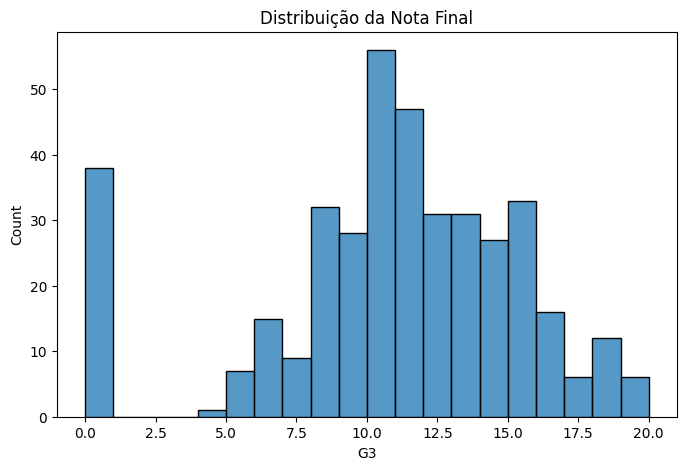

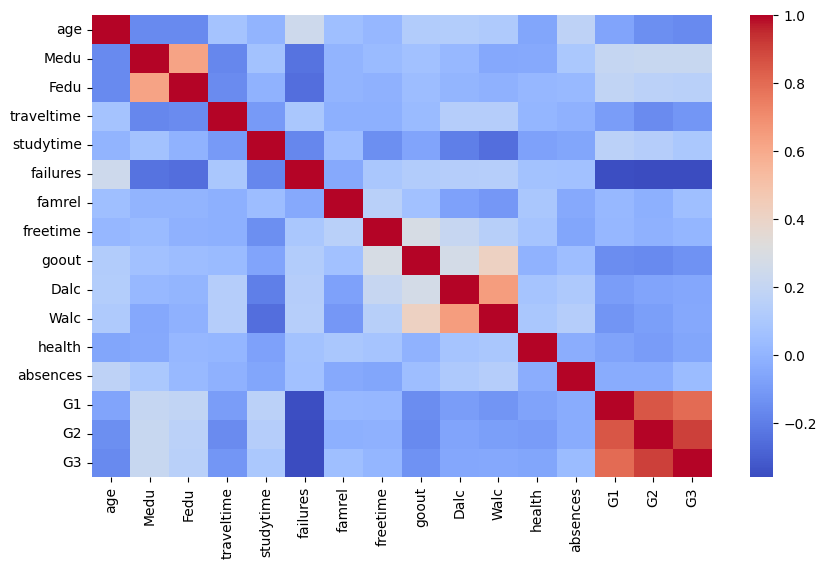

In [7]:
df.isnull().sum()

plt.figure(figsize=(8,5))
sns.histplot(df['G3'], bins=20)
plt.title('Distribuição da Nota Final')
plt.show()




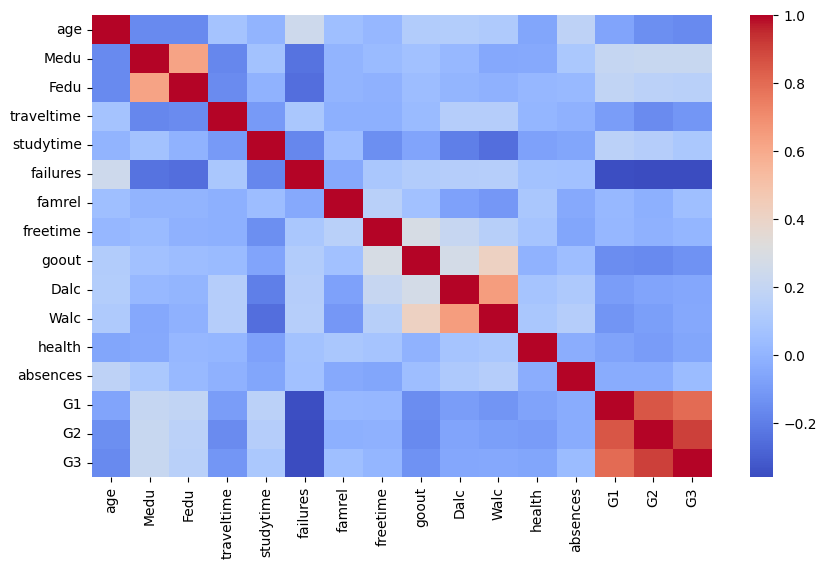

In [19]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.show()

Pré-processamento

In [21]:
df = pd.get_dummies(df, drop_first=True)

X = df.drop('G3', axis=1)
y = df['G3']


print (X)
print (y)

     age  Medu  Fedu  traveltime  studytime  failures  famrel  freetime  \
0     18     4     4           2          2         0       4         3   
1     17     1     1           1          2         0       5         3   
2     15     1     1           1          2         3       4         3   
3     15     4     2           1          3         0       3         2   
4     16     3     3           1          2         0       4         3   
..   ...   ...   ...         ...        ...       ...     ...       ...   
390   20     2     2           1          2         2       5         5   
391   17     3     1           2          1         0       2         4   
392   21     1     1           1          1         3       5         5   
393   18     3     2           3          1         0       4         4   
394   19     1     1           1          1         0       3         2   

     goout  Dalc  ...  guardian_mother  guardian_other  schoolsup_yes  \
0        4     1  ...     

Divisão entre treino e teste

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("Treinos")
print (len(X_train))
print (len(y_train))
print("\nTestes")
print (len(X_test))
print (len(y_test))

print("\nTotal")
print((len(X_train)+ len(X_test)))


Treinos
316
316

Testes
79
79

Total
395


Treinando o Random Forest

In [30]:
modelo = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

modelo.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

Previsões

In [32]:
y_pred = modelo.predict(X_test)

print (y_pred)

[ 8.24  11.77   6.725  9.56   8.82  12.85  18.685  6.855  7.005 13.345
 15.62   6.83  13.985 11.785 14.11   8.165  1.125 10.525 15.425  6.45
 14.105 15.71  15.205  6.39   6.27  18.48  10.535  9.575 18.125 10.645
  8.565  8.575 15.305 13.085  1.005  6.495  0.095 15.    11.8    7.715
  6.04  10.29  14.02   8.345 14.835  6.635 11.575 14.18  12.65  15.55
 13.43  15.335 10.435  8.65   5.755 13.26  10.745  1.29  15.535 15.95
 13.33   8.76   8.245  6.4    7.195 17.96   9.42   9.1    9.6   15.285
  8.28   9.83  13.58  18.435 10.79   5.83   8.755 14.21   5.805]


Avaliar o modelo

In [33]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 1.1734177215189876
RMSE: 1.9666317668361595
R²: 0.8113810489794643


Importancia das variáveis

         Variavel  Importancia
14             G2     0.788004
12       absences     0.114189
28    reason_home     0.019827
0             age     0.009574
13             G1     0.005851
6          famrel     0.005042
11         health     0.004425
8           goout     0.004332
33  schoolsup_yes     0.004255
40   romantic_yes     0.003987


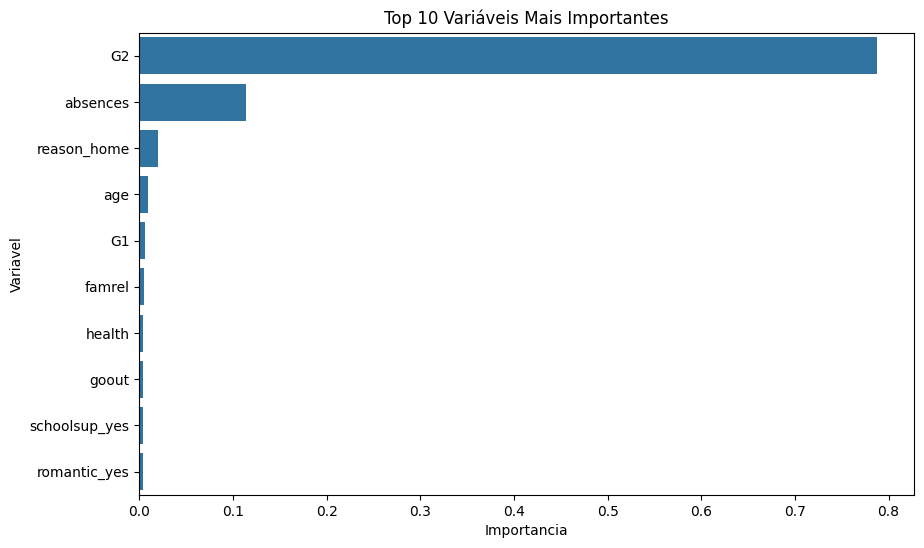

In [13]:
importances = pd.DataFrame({
    'Variavel': X.columns,
    'Importancia': modelo.feature_importances_
})

importances = importances.sort_values(
    by='Importancia',
    ascending=False
)

print(importances.head(10))



plt.figure(figsize=(10,6))

sns.barplot(
    data=importances.head(10),
    x='Importancia',
    y='Variavel'
)

plt.title('Top 10 Variáveis Mais Importantes')
plt.show()

Conclusão

In [14]:
df['Aprovado'] = (df['G3'] >= 10).astype(int)

from sklearn.ensemble import RandomForestClassifier